In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings('ignore')

/kaggle/input/extrovert-vs-introvert-behavior-data/personality_datasert.csv
/kaggle/input/extrovert-vs-introvert-behavior-data/personality_dataset.csv


In [2]:
# Carregando o arquivo csv

data = pd.read_csv("/kaggle/input/extrovert-vs-introvert-behavior-data/personality_dataset.csv")

## EDA
Aqui vamos olhar um pouco mais sobre o conjunto de dados e ver informações gerais.

In [3]:
# Temos 8 colunas e 2900 linhas
data.shape

(2900, 8)

In [4]:
# Vamos ver quais os nomes das colunas

print(data.columns)

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')


In [5]:
# Informações sobre as primeiras cinco linhas
data.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [6]:
# Informações estatísticas das colunas numéricas
data.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [7]:
# Vamos fazer uma cópia do conjunto para alterações
df = data.copy()

In [8]:
# Criando uma lista com as colunas 'object' e/ou 'category'
obj = [col for col in data.columns if data[col].dtype in ['object', 'category']]

In [9]:
le = LabelEncoder()

In [10]:
# Transformando as colunas em númericas

for col in obj:
    df[col] = le.fit_transform(df[col].astype(str))

In [11]:
df.shape

(2900, 8)

In [12]:
# Me livrando de possíveis valores NaN depois da conversão
df.dropna(inplace=True)

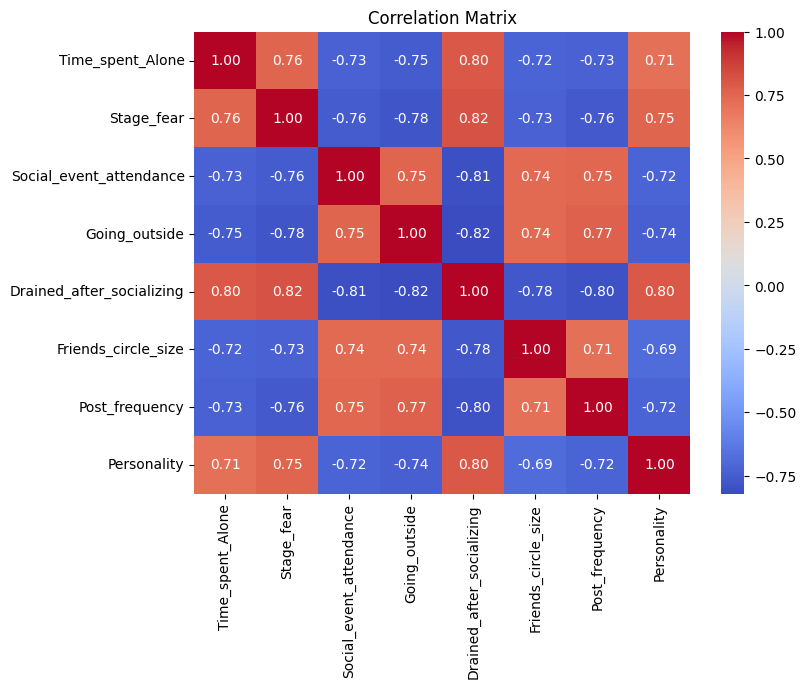

In [13]:
# Temos algumas colunas com informações númericas e outras com dados categoricos, vamos ver a importância das colunas
plt.figure(figsize=(8, 6))                     # Define o tamanho da figura
sns.heatmap(                                   # Cria o heatmap
    df.corr(),                               # Matriz de correlação entre as colunas numéricas
    annot=True,                                # Mostra os valores nas células
    cmap="coolwarm",                           # Define o esquema de cores
    fmt=".2f"                                  # Formato dos números (duas casas decimais)
)
plt.title("Correlation Matrix") 
plt.show()                                     

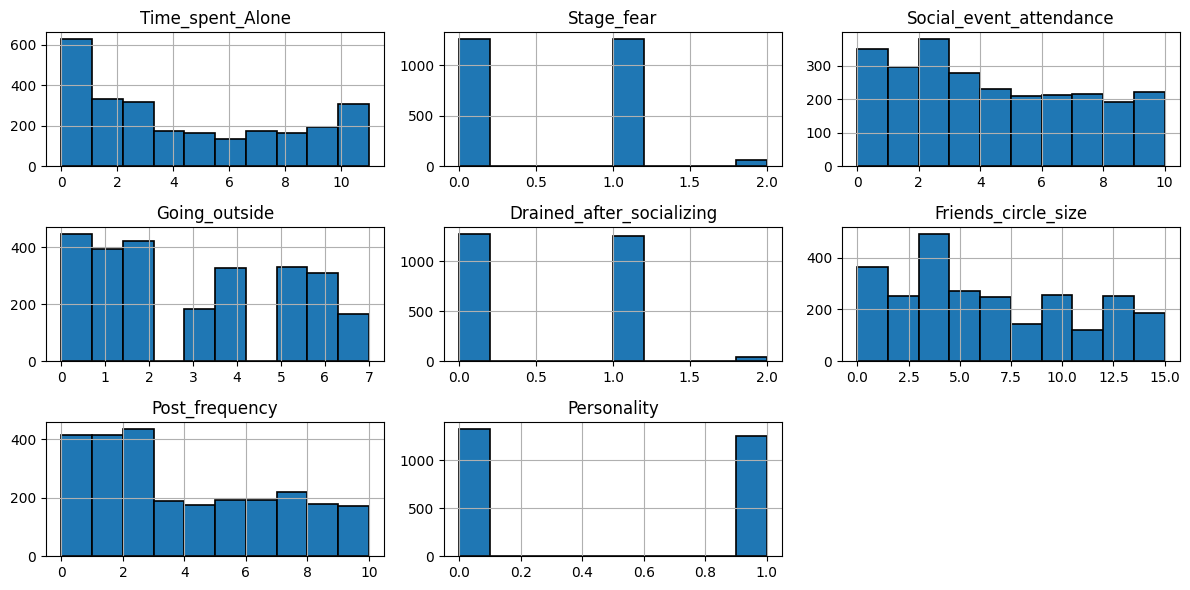

In [14]:
# Vamos ver todos os histogramas de frequência

df.hist(edgecolor='black', linewidth=1.2)

fig = plt.gcf()
fig.set_size_inches(12, 6)

plt.tight_layout()
plt.show()

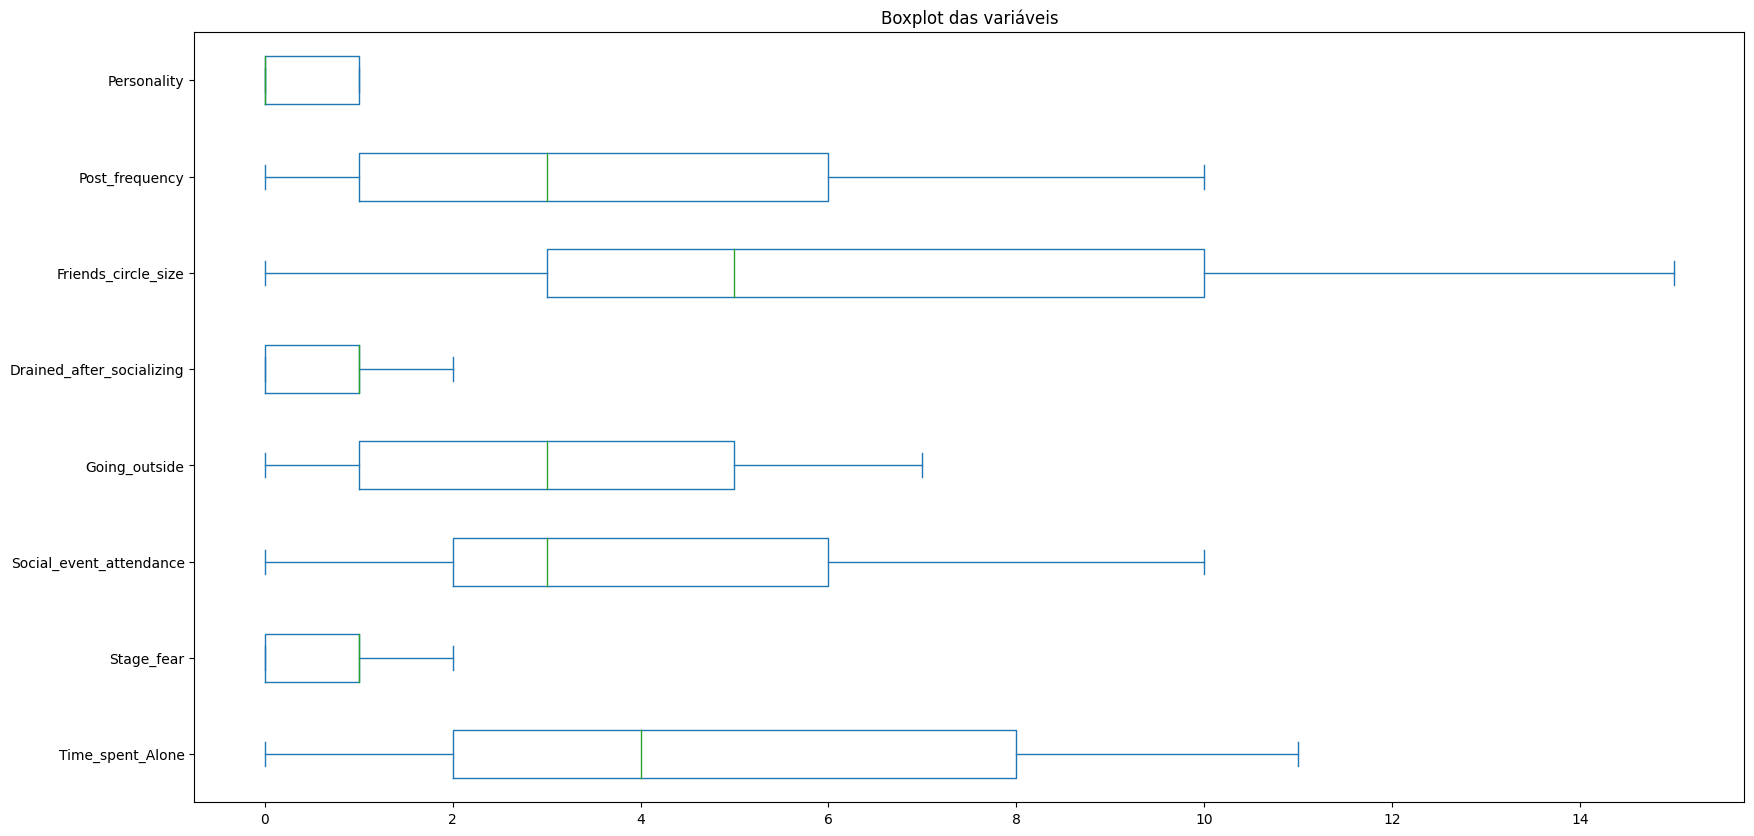

In [15]:
df.select_dtypes(include='number').plot.box(figsize=(20,10), vert=False)
plt.title("Boxplot das variáveis")
plt.show()

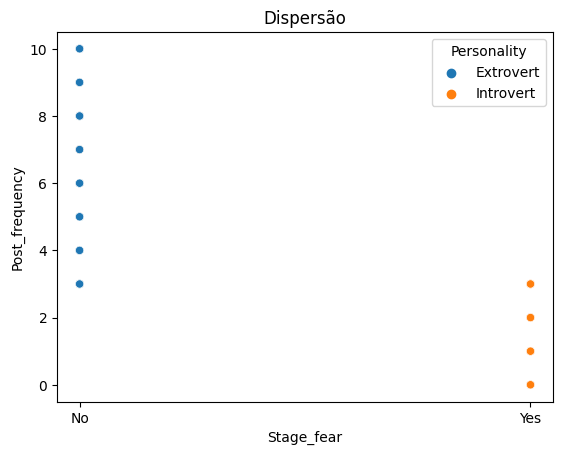

In [16]:
# Vamos ver um pouco mais sobre a dispersão dos dados
sns.scatterplot(
    data=data,
    x='Stage_fear',
    y='Post_frequency',
    hue='Personality',         
)

plt.title('Dispersão')
plt.show()

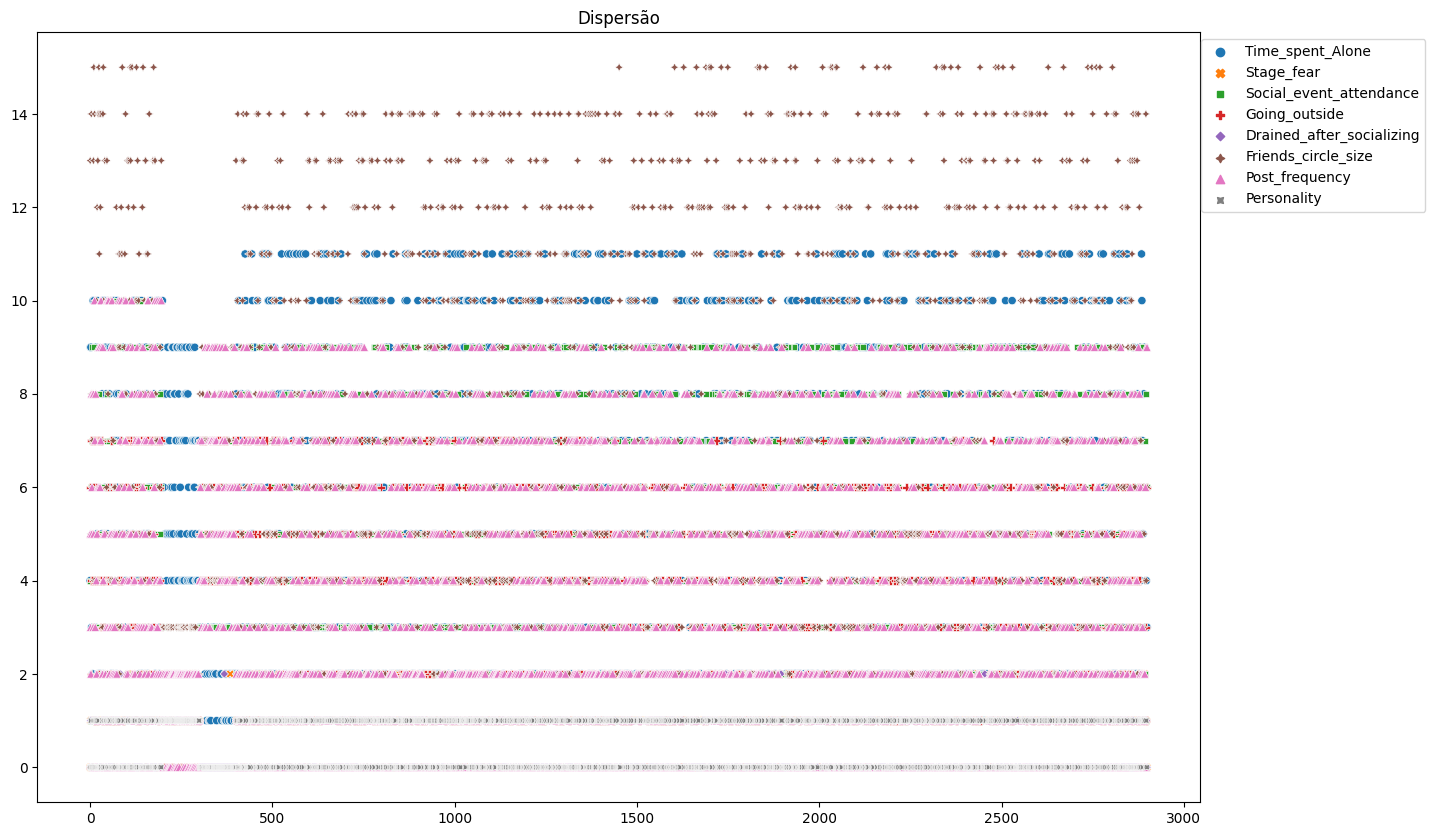

In [17]:
# Podemos separa linearmente as classes com uma certa quantidade de erro

plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=df,
)

plt.title('Dispersão')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
plt.show()

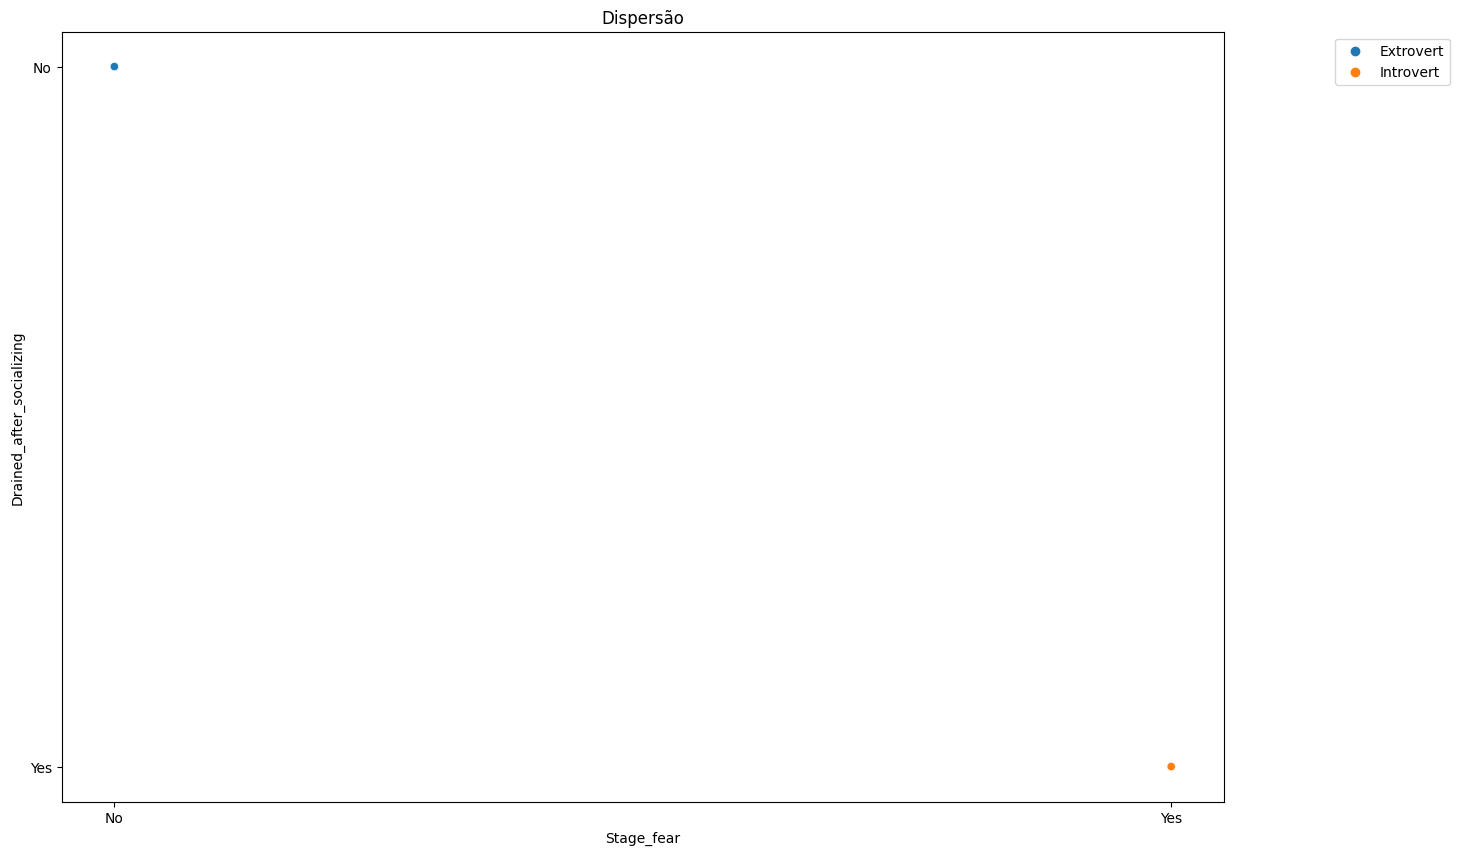

In [18]:
plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=data,
    x='Stage_fear',
    y='Drained_after_socializing',
    hue='Personality',
)

plt.title('Dispersão')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
plt.show()

# Classificando os grupos

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import make_pipeline

In [20]:
X = df.drop('Personality', axis=1)
y = df['Personality']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Decision Tree

In [22]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [23]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Acurácia: {acc:.2f}')

Acurácia: 0.87


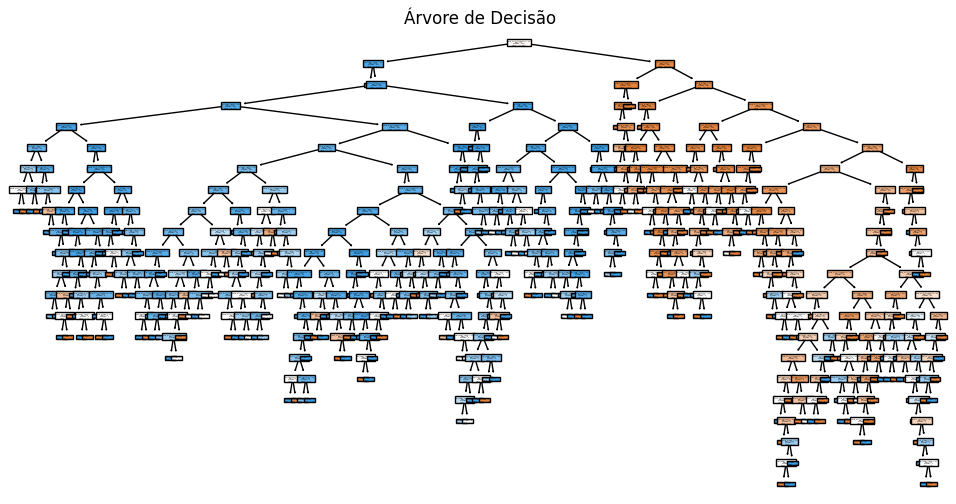

In [24]:
plt.figure(figsize=(12, 6))
plot_tree(clf, filled=True, feature_names=X.columns)
plt.title("Árvore de Decisão")
plt.show()

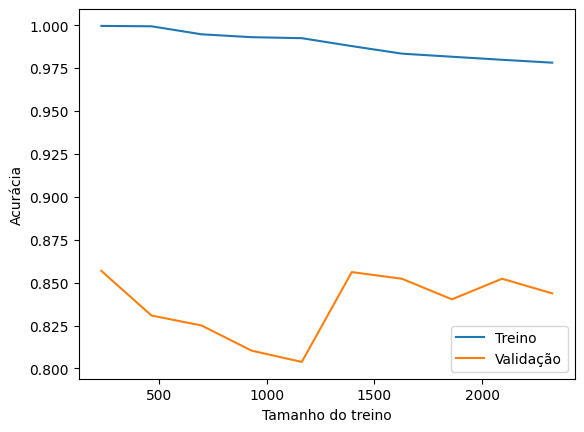

In [25]:
train_sizes, train_scores, val_scores = learning_curve(
    clf, X, y, cv=10, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Treino')
plt.plot(train_sizes, np.mean(val_scores, axis=1), label='Validação')
plt.xlabel('Tamanho do treino')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

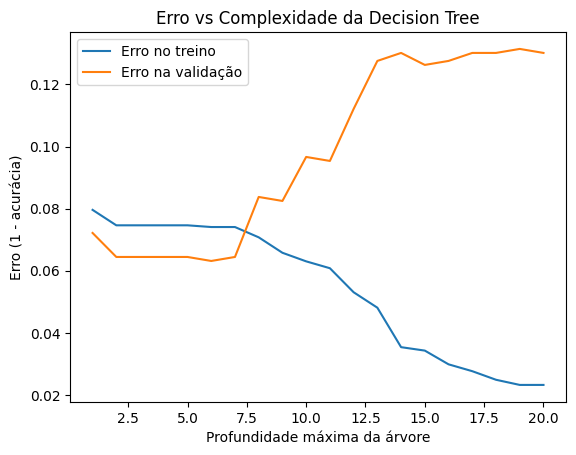

In [26]:
# O modelo tem dificuldade para generalizar, ele se adaptou ao conjunto de dados.

max_depths = range(1, 21)
train_errors = []
test_errors = []

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_errors.append(1 - accuracy_score(y_train, y_train_pred))
    test_errors.append(1 - accuracy_score(y_test, y_test_pred))

plt.plot(max_depths, train_errors, label='Erro no treino')
plt.plot(max_depths, test_errors, label='Erro na validação')
plt.xlabel('Profundidade máxima da árvore')
plt.ylabel('Erro (1 - acurácia)')
plt.legend()
plt.title('Erro vs Complexidade da Decision Tree')
plt.show()

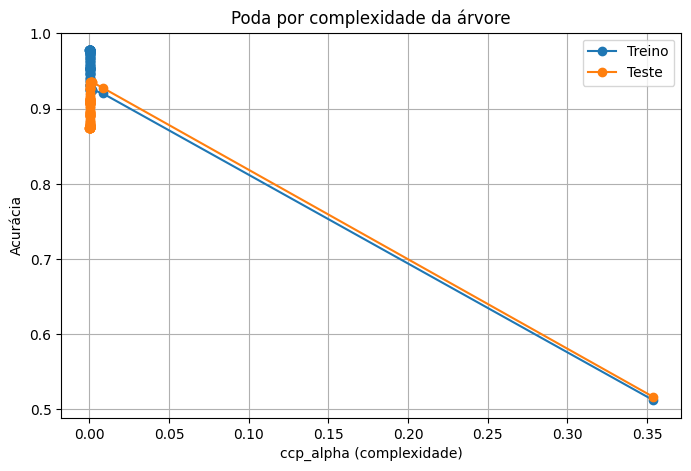

In [27]:
# Passo 1: Treina a árvore completa
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Passo 2: Treina várias árvores com diferentes alphas
models = []
for alpha in ccp_alphas:
    m = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    m.fit(X_train, y_train)
    models.append(m)

# Passo 3: Avalia erro para cada alpha
train_scores = [m.score(X_train, y_train) for m in models]
test_scores = [m.score(X_test, y_test) for m in models]

# Passo 4: Plot
plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, train_scores, marker='o', label='Treino')
plt.plot(ccp_alphas, test_scores, marker='o', label='Teste')
plt.xlabel("ccp_alpha (complexidade)")
plt.ylabel("Acurácia")
plt.title("Poda por complexidade da árvore")
plt.legend()
plt.grid()
plt.show()


In [28]:
path = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

models = [DecisionTreeClassifier(random_state=0, ccp_alpha=alpha).fit(X_train, y_train) for alpha in ccp_alphas]

In [29]:
test_scores = [accuracy_score(y_test, model.predict(X_test)) for model in models]
melhor_indice = np.argmax(test_scores)
melhor_modelo = models[melhor_indice]

In [30]:
y_pred = melhor_modelo.predict(X_test)
print("Acurácia do modelo podado:", accuracy_score(y_test, y_pred))

Acurácia do modelo podado: 0.9355670103092784


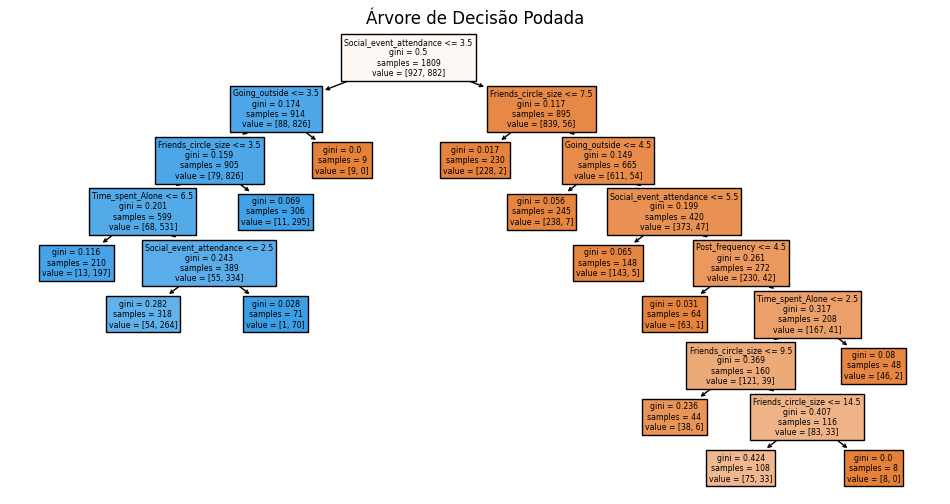

In [31]:
plt.figure(figsize=(12, 6))
plot_tree(melhor_modelo, filled=True, feature_names=X.columns)
plt.title("Árvore de Decisão Podada")
plt.show()

# Naive Bayes

In [32]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
model = make_pipeline(encoder, CategoricalNB())
model.fit(X, y)

Pipeline(steps=[('ordinalencoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('categoricalnb', CategoricalNB())])

In [33]:
y_nB = model.predict(X_test)

# Avaliação
print(accuracy_score(y_test, y_nB))

0.9355670103092784
